<a href="https://colab.research.google.com/github/SomTu/01RAD/blob/main/HW/01RAD_Ex02_HW_Satransky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/HW/01RAD_Ex02_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 02: Regression to the mean (Galton's heights)

In 1886 Francis Galton compared the heights of 1,078 fathers and their adult sons and noticed that sons of tall fathers tend to be shorter than their fathers, and sons of short fathers taller. He called the phenomenon *regression towards mediocrity*; the name stuck to the whole method (Lecture 1, history). The data are the `fsdata.csv` file from Exercise 01 (heights in inches).

Model of Lecture 1: $Y_i = \beta_0 + \beta_1 x_i + e_i$ with $x_i$ the father's height and $Y_i$ the son's height, independent errors $e_i \sim (0, \sigma^2)$. Tools of Lecture 2 (slides pp. 14–32 of the lecture PDF): standard errors $\widehat{\sigma}(\widehat{\beta}_j) = s_n \sqrt{\delta_j}$, **confidence intervals** (Czech: intervaly spolehlivosti) $\widehat{\beta}_j \pm t_{1-\alpha/2}(n-2)\,\widehat{\sigma}(\widehat{\beta}_j)$ and the **tests** (testy hypotéz) with statistics $T_j = (\widehat{\beta}_j - b)/\widehat{\sigma}(\widehat{\beta}_j)$ compared with $t_{1-\alpha/2}(n-2)$.

## Submission
Work through the tasks in this notebook (code plus short written answers in markdown cells; Python or R, as you prefer). Submit through GitHub **before the next exercise**: fork `francji1/01RAD`, save the notebook into the `HW/` folder as `01RAD_Ex02_HW_<Surname>.ipynb`, with your surname in place of `<Surname>` and without the brackets, for example `01RAD_Ex02_HW_Novak.ipynb` (team: surnames joined by an underscore), and open a pull request to `main`. The pull request should add your one file only; do not modify or delete other files. A selected student solution, and a reference solution if needed, will be published in `HW/` a week later.

Useful calls: `stats.t.ppf(1 - alpha/2, df)` for the $t$ quantile, `stats.t.sf(abs(T), df)` and `stats.t.cdf(T, df)` for tail probabilities, `model.conf_int(alpha)`, `model.t_test('father = 1')`, `model.predict(pd.DataFrame({'father': [...]}))`, `np.corrcoef`, `df.sample(n, random_state=...)`.

## Data

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_fsdata = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/fsdata.csv'
fsdata = pd.read_csv(url_fsdata, index_col=0)
print(f'Rows: {fsdata.shape[0]}, columns: {fsdata.shape[1]}')
fsdata.describe().T

Rows: 1078, columns: 2


,count,mean,std,min,25%,50%,75%,max
father,1078.0,67.687097,2.744868,59.00800,65.787735,67.76660,69.60298,75.43393
son,1078.0,68.684070,2.814702,58.50708,66.931232,68.61582,70.46597,78.36479


## Task 01 - Fit and recap
Fit the regression of `son` on `father`. Compute $\widehat{\beta}_0$, $\widehat{\beta}_1$, $s_n$ and both standard errors by hand (formulas of Lectures 1 and 2) and check them against `statsmodels` (R: `summary(lm(son ~ father))`). Interpret $\widehat{\beta}_1$ in one sentence.

In [34]:
# your solution
m = smf.ols('son ~ father', data=fsdata).fit()

x, y = fsdata['father'].to_numpy(), fsdata['son'].to_numpy()
n = len(x)

Sxx = np.sum((x - x.mean())**2)
b1 = np.sum((x - x.mean()) * (y - y.mean())) / Sxx
b0 = y.mean() - b1 * x.mean()

resid = y - (b0 + b1 * x)
s_n = np.sqrt(np.sum(resid**2) / (n - 2))   # residual std. error, df = n-2

se_b1 = s_n / np.sqrt(Sxx)
se_b0 = s_n * np.sqrt(1/n + x.mean()**2 / Sxx)

hand = pd.DataFrame(
    {'by hand': [b0, b1, s_n, se_b0, se_b1],
     'statsmodels': [m.params['Intercept'], m.params['father'], np.sqrt(m.scale),
                     m.bse['Intercept'], m.bse['father']]},
    index=['intercept', 'slope', 's_n', 'SE(intercept)', 'SE(slope)'])
hand['match'] = np.isclose(hand['by hand'], hand['statsmodels'])
hand

,by hand,statsmodels,match
intercept,33.886604,33.886604,True
slope,0.514093,0.514093,True
s_n,2.436556,2.436556,True
SE(intercept),1.832354,1.832354,True
SE(slope),0.027049,0.027049,True


# Interpretation


The slope ~0.51 points to prediction that if we take a father one inch higher, his son will, on average, by half an inch shorter.

## Task 02 - Confidence intervals
Compute the 95 % and the 99 % confidence intervals for $\beta_0$ and $\beta_1$ by hand, using the $t$ quantile, and compare with `conf_int` (R: `confint`). Why is the 99 % interval wider? Compare the widths of the intervals for $\beta_0$ and $\beta_1$ in absolute terms and relative to the estimates: which parameter is estimated more precisely? Relate your answer to the remark in Lecture 2.

In [35]:
# your solution
alpha_levels = [0.05, 0.01]
rows = []
for a in alpha_levels:
    tq = stats.t.ppf(1 - a/2, df=n - 2)
    ci = m.conf_int(alpha=a)
    for name, est, se in [('Intercept', b0, se_b0), ('father', b1, se_b1)]:
        lo, hi = est - tq * se, est + tq * se
        rows.append({'level': f'{1-a:.0%}', 'param': name, 't_q': tq,
                     'est': est,
                     'lo (hand)': lo, 'hi (hand)': hi,
                     'lo (sm)': ci.loc[name, 0], 'hi (sm)': ci.loc[name, 1],
                     'width': hi - lo, 'rel. width': (hi - lo) / abs(est),
                     'match': np.allclose([lo, hi], ci.loc[name].to_numpy())})
pd.DataFrame(rows)

,level,param,t_q,est,lo (hand),hi (hand),lo (sm),hi (sm),width,rel. width,match
0,95%,Intercept,1.962171,33.886604,30.291213,37.481996,30.291213,37.481996,7.190784,0.212201,True
1,95%,father,1.962171,0.514093,0.461019,0.567167,0.461019,0.567167,0.106148,0.206477,True
2,99%,Intercept,2.580406,33.886604,29.158387,38.614822,29.158387,38.614822,9.456434,0.279061,True
3,99%,father,2.580406,0.514093,0.444296,0.583890,0.444296,0.583890,0.139593,0.271533,True


# Explanation

The 99% interval is wider, because it is such an interval that the probability that it contains the true parameter is 0.99. Therefore, if we demand it to contain it with bigger probability, it has to be wider to include the true value.


Absolute widths of the CIs are vastly different, but in relative terms, they are very close, 'father' being a bit closer.


## Task 03 - Is the father's height informative?
Test $H_0: \beta_1 = 0$ against $H_1: \beta_1 \neq 0$ at $\alpha = 0.05$: report $T_1$, the critical value $t_{0.975}(n-2)$, the $p$-value and the decision. What does the rejection say about the relationship, and what does it *not* say (think of the lecture's warning about linearity)?

In [36]:
# your solution

T1 = b1 / se_b1
t_crit = stats.t.ppf(0.975, df=n - 2)
p_val = 2 * stats.t.sf(abs(T1), df=n - 2)

print(f'T1 = {T1:.4f}, t_crit = {t_crit:.4f}, p = {p_val:.3g}')
print('Reject H0: beta1 = 0' if abs(T1) > t_crit else 'Fail to reject H0: beta1 = 0')
print(f"statsmodels: t = {m.tvalues['father']:.4f}, p = {m.pvalues['father']:.3g}")

T1 = 19.0062, t_crit = 1.9622, p = 1.12e-69
Reject H0: beta1 = 0
statsmodels: t = 19.0062, p = 1.12e-69


# Answer

he rejection of $\beta_1$ being zero means, that we have enough evidence against the fact that we would NOT register a linear relationship stemming from father to son. We can interpret it as having enough evidence for the fact that there is some linear relationship between father and son.

The rejection does not say the variables are neccessairly linearly dependent, there can be other type of dependence, we only caught the linear part.


## Task 04 - Regression to the mean
If sons were on average exactly as tall as their fathers plus a constant, the slope would be $\beta_1 = 1$. Test $H_0: \beta_1 = 1$ against $H_1: \beta_1 \neq 1$ (the test with a given candidate value $b_1$ from Lecture 2) and also against the **one-sided alternative** (jednostranná alternativa) $H_1: \beta_1 < 1$: the lecture treats two-sided alternatives, for the one-sided one use the same statistic $T = (\widehat{\beta}_1 - 1)/\widehat{\sigma}(\widehat{\beta}_1)$, reject when $T < -t_{1-\alpha}(n-2)$, and the $p$-value is $P(t(n-2) < T)$. Check the duality of the two-sided test with the 95 % confidence interval from Task 02. Explain in your own words why Galton spoke of *regression* (regrese k průměru) and what the estimated slope says about sons of very tall and very short fathers.

In [37]:
# your solution
b1_null = 1.0
df = n - 2
alpha = 0.05

T = (b1 - b1_null) / se_b1

# two-sided: reject when |T| > t_{1-alpha/2}(n-2)
t_crit_two = stats.t.ppf(1 - alpha/2, df=df)
p_two = 2 * stats.t.sf(abs(T), df=df)

# one-sided (H1: beta1 < 1): reject when T < -t_{1-alpha}(n-2)
t_crit_one = stats.t.ppf(1 - alpha, df=df)
p_one = stats.t.cdf(T, df=df)          # P(t(n-2) < T)

print(f'T = {T:.4f}  (df = {df})')
print(f'Two-sided: t_crit = {t_crit_two:.4f}, p = {p_two:.3g} -> '
      f"{'reject' if abs(T) > t_crit_two else 'fail to reject'} H0: beta1 = 1")
print(f'One-sided (<): -t_crit = {-t_crit_one:.4f}, p = {p_one:.3g} -> '
      f"{'reject' if T < -t_crit_one else 'fail to reject'} H0 in favour of beta1 < 1")

# cross-check with statsmodels
tt = m.t_test('father = 1')
print(f'statsmodels two-sided: t = {tt.tvalue.item():.4f}, p = {tt.pvalue.item():.3g}')

# duality with the 95% CI from Task 02
lo, hi = b1 - t_crit_two * se_b1, b1 + t_crit_two * se_b1
print(f'95% CI for beta1: [{lo:.4f}, {hi:.4f}]')
print('1 inside CI:', lo <= 1 <= hi, '| two-sided test rejects:', abs(T) > t_crit_two)
assert (lo <= 1 <= hi) == (abs(T) <= t_crit_two)   # duality holds


T = -17.9641  (df = 1076)
Two-sided: t_crit = 1.9622, p = 2.61e-63 -> reject H0: beta1 = 1
One-sided (<): -t_crit = -1.6463, p = 1.3e-63 -> reject H0 in favour of beta1 < 1
statsmodels two-sided: t = -17.9641, p = 2.61e-63
95% CI for beta1: [0.4610, 0.5672]
1 inside CI: False | two-sided test rejects: True


# Answer

The fitted line is $\hat{y} = \bar{y} + \widehat{\beta}_1 (x - \bar{x})$, which means that the deviation of sons's heights is proportional to $\beta_1$ times the deviation in fathers' heights. Because $\beta_1 \approx 0.5$, very tall fathers's sons have, on average, half as much deviation (they are, on average, half times as deviated from their mean). Very short fathers, similarly, have, on average, twice as much deviation from father's mean than sons do from sons'.

This is regression to the mean: extreme fathers have less extreme sons on average. It does not mean that heights are converging or that the population is changing. The spread stays about the same, because individual sons scatter around the line.

## Task 05 - The intercept
Test $H_0: \beta_0 = 0$. Then write $\widehat{\beta}_0 = \overline{y} - \widehat{\beta}_1 \overline{x}$, plug in the sample means and explain why the intercept is far from zero even though sons are on average only about one inch taller than their fathers. Would a model through the origin make sense here?

In [38]:
# your solution
T0 = b0 / se_b0
p0 = 2 * stats.t.sf(abs(T0), df=n - 2)
t_crit = stats.t.ppf(0.975, df=n - 2)

print(f'T0 = {T0:.4f}, t_crit = {t_crit:.4f}, p = {p0:.3g} -> '
      f"{'reject' if abs(T0) > t_crit else 'fail to reject'} H0: beta0 = 0")
print(f"statsmodels: t = {m.tvalues['Intercept']:.4f}, p = {m.pvalues['Intercept']:.3g}")

# intercept from the means
xbar, ybar = x.mean(), y.mean()
print(f'ybar = {ybar:.3f}, xbar = {xbar:.3f}, ybar - xbar = {ybar - xbar:.3f}')
print(f'b0 = ybar - b1*xbar = {ybar:.3f} - {b1:.4f}*{xbar:.3f} = {ybar - b1*xbar:.3f}')
print(f'Decomposition: (ybar - xbar) + (1 - b1)*xbar = {(ybar - xbar):.3f} + {(1 - b1)*xbar:.3f}')
print(f'Range of fathers\' heights: {x.min():.1f} to {x.max():.1f}')


T0 = 18.4935, t_crit = 1.9622, p = 1.6e-66 -> reject H0: beta0 = 0
statsmodels: t = 18.4935, p = 1.6e-66
ybar = 68.684, xbar = 67.687, ybar - xbar = 0.997
b0 = ybar - b1*xbar = 68.684 - 0.5141*67.687 = 33.887
Decomposition: (ybar - xbar) + (1 - b1)*xbar = 0.997 + 32.890
Range of fathers' heights: 59.0 to 75.4


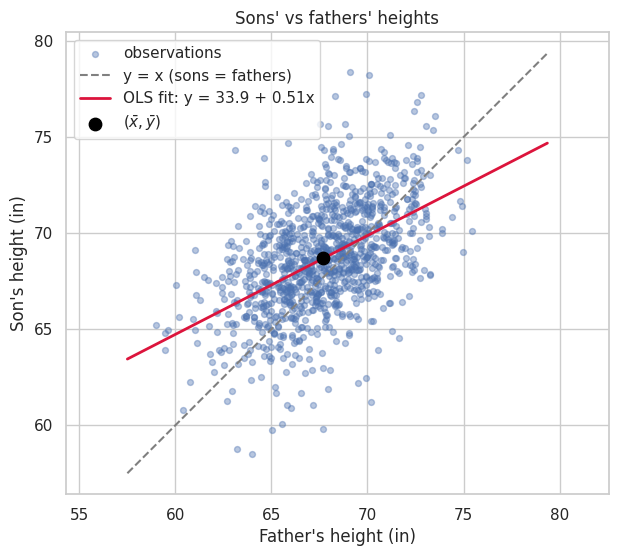

In [39]:
# your solution
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y, alpha=0.4, s=18, label='observations')

grid = np.linspace(min(x.min(), y.min()) - 1, max(x.max(), y.max()) + 1, 100)
ax.plot(grid, grid, '--', color='gray', label='y = x (sons = fathers)')
ax.plot(grid, b0 + b1 * grid, color='crimson', lw=2,
        label=f'OLS fit: y = {b0:.1f} + {b1:.2f}x')
ax.scatter([x.mean()], [y.mean()], color='black', s=80, zorder=5, label=r'$(\bar{x}, \bar{y})$')

ax.set_xlabel("Father's height (in)")
ax.set_ylabel("Son's height (in)")
ax.set_title("Sons' vs fathers' heights")
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
plt.show()

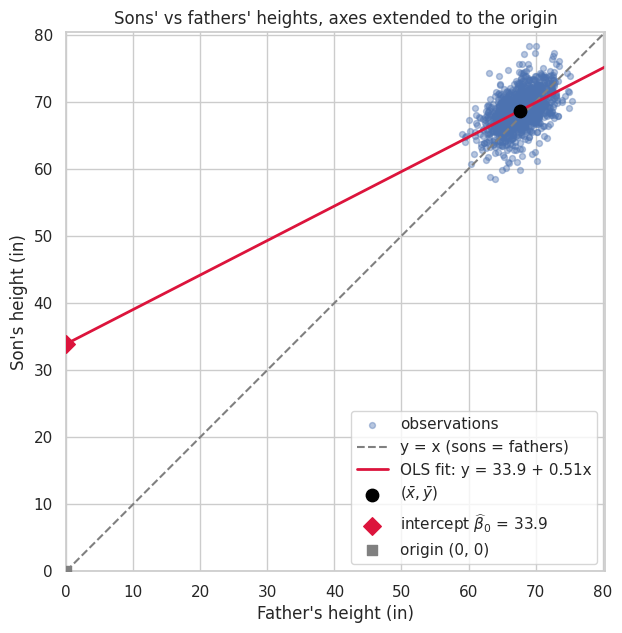

In [40]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x, y, alpha=0.4, s=18, label='observations')

grid = np.linspace(0, max(x.max(), y.max()) + 2, 200)
ax.plot(grid, grid, '--', color='gray', label='y = x (sons = fathers)')
ax.plot(grid, b0 + b1 * grid, color='crimson', lw=2,
        label=f'OLS fit: y = {b0:.1f} + {b1:.2f}x')

ax.scatter([x.mean()], [y.mean()], color='black', s=80, zorder=5,
           label=r'$(\bar{x}, \bar{y})$')
ax.scatter([0], [b0], color='crimson', s=80, marker='D', zorder=5,
           label=f'intercept $\\widehat{{\\beta}}_0$ = {b0:.1f}')
ax.scatter([0], [0], color='gray', s=60, marker='s', zorder=5, label='origin (0, 0)')

ax.set_xlim(0, grid.max())
ax.set_ylim(0, grid.max())
ax.set_aspect('equal')
ax.set_xlabel("Father's height (in)")
ax.set_ylabel("Son's height (in)")
ax.set_title("Sons' vs fathers' heights, axes extended to the origin")
ax.legend(loc='lower right')
plt.show()

# Answer

The model has to pass through $(\bar{x}, \bar{y})$, since $\hat{\beta_0} = \bar{y} - \hat{\beta_1}\bar{x} \Leftrightarrow \bar{y} = \hat{\beta_0} + \hat{\beta_1}\bar{x}$. $(\hat{x}, \hat{y}) \approx (67, 68)$ and the slope is $\hat{\beta_1} \approx 0.5$, so the high intercept follows from both of these facts.

In the case of a model without intercept, the slope would have to be around $1$. From a quick look at the scatterplot, there are no datapoints anywhere near the origin. Even more, data from around the origin make little to no sense (people being 20 or less inches have never been even recorded). Therefore it makes more sense to let the model minimize the local error in the data cloud instead of forcing a no-intercept model.

## Task 06 - Point predictions
Predict the mean height of sons whose fathers are 60, 64, 68, 72 and 76 inches tall and tabulate the difference *predicted son minus father*. For which father's height do the two coincide? (Confidence and prediction intervals for these predictions come in Lecture 4; here point predictions are enough.)

In [41]:
# your solution
fathers = np.array([60, 64, 68, 72, 76])
pred = b0 + b1 * fathers

pred_tab = pd.DataFrame({'father': fathers,
                         'predicted son': pred,
                         'son - father': pred - fathers})
print(pred_tab.round(2).to_string(index=False))

# father's height where the predicted son equals the father: b0 + b1*x = x
x_star = b0 / (1 - b1)
print(f'Predicted son = father at x* = b0 / (1 - b1) = {x_star:.2f} in')

# cross-check with statsmodels
print(m.predict(pd.DataFrame({'father': fathers})).round(2).to_numpy())

 father  predicted son  son - father
     60          64.73          4.73
     64          66.79          2.79
     68          68.84          0.84
     72          70.90         -1.10
     76          72.96         -3.04
Predicted son = father at x* = b0 / (1 - b1) = 69.74 in
[64.73 66.79 68.84 70.9  72.96]


## Task 07 - Reverse regression
Fit the reverse regression of `father` on `son` and report its slope. Verify numerically that the product of the two slopes equals the square of the sample correlation coefficient $r$ of the two heights (`np.corrcoef`), and explain why both slopes are smaller than 1. Is regression to the mean a causal effect of fathers on sons, or a statistical property of the two distributions?

In [42]:
# your solution
m_rev = smf.ols('father ~ son', data=fsdata).fit()
b1_rev = m_rev.params['son']

r = np.corrcoef(x, y)[0, 1]

print(f'slope son ~ father   : {b1:.4f}')
print(f'slope father ~ son   : {b1_rev:.4f}')
print(f'product of slopes    : {b1 * b1_rev:.4f}')
print(f'r^2                  : {r**2:.4f}   (r = {r:.4f})')
print('product == r^2:', np.isclose(b1 * b1_rev, r**2))
print(f'sd(father) = {x.std(ddof=1):.3f}, sd(son) = {y.std(ddof=1):.3f}')
print()

# turning point: father's height where predicted son = father
x_star = b0 / (1 - b1)

# equivalent form via the means: x* = xbar + (ybar - xbar) / (1 - b1)
x_star_means = x.mean() + (y.mean() - x.mean()) / (1 - b1)

print(f'x* = {x_star:.2f} in  (via means: {x_star_means:.2f} in)')
print('forms agree:', np.isclose(x_star, x_star_means))
print(f'check, predicted son - father at x*: {b0 + b1 * x_star - x_star:.2e}')

slope son ~ father   : 0.5141
slope father ~ son   : 0.4889
product of slopes    : 0.2513
r^2                  : 0.2513   (r = 0.5013)
product == r^2: True
sd(father) = 2.745, sd(son) = 2.815

x* = 69.74 in  (via means: 69.74 in)
forms agree: True
check, predicted son - father at x*: 0.00e+00


# Answer

The reverse slope is also below 1, because the product of the two slopes equals $r^2$. Height is only partly shared between father and son, so extreme values of one are matched by less extreme values of the other, in both directions. This is a statistical property of imperfect correlation, not a causal effect of fathers on sons.

## Task 08 - Sample size and precision
Draw random subsamples of 30, 100 and 300 father-son pairs (fix the random seed), fit the model in each and compare the widths of the 95 % intervals for $\beta_1$ with the full-sample interval. Explain the pattern through $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / S_{xx}$. *Optional:* repeat the subsampling with $n = 100$ five hundred times, treat the full-sample $\widehat{\beta}_1$ as the true value and estimate how often the 95 % interval covers it.

In [43]:
# your solution
rng = np.random.default_rng(42)

def slope_ci(data, alpha=0.05):
    mod = smf.ols('son ~ father', data=data).fit()
    lo, hi = mod.conf_int(alpha=alpha).loc['father']
    return mod.params['father'], lo, hi, mod.bse['father']

full_b, full_lo, full_hi, full_se = slope_ci(fsdata)
rows = [{'n': len(fsdata), 'b1': full_b, 'lo': full_lo, 'hi': full_hi,
         'width': full_hi - full_lo, 'width / full': 1.0,
         'SE(b1)': full_se, 'Sxx': Sxx}]

for k in [30, 100, 300]:
    sub = fsdata.sample(n=k, random_state=int(rng.integers(1_000_000)))
    b, lo, hi, se = slope_ci(sub)
    Sxx_k = np.sum((sub['father'] - sub['father'].mean())**2)
    rows.append({'n': k, 'b1': b, 'lo': lo, 'hi': hi, 'width': hi - lo,
                 'width / full': (hi - lo) / (full_hi - full_lo),
                 'SE(b1)': se, 'Sxx': Sxx_k})
display(pd.DataFrame(rows).round(4))

# optional: coverage of the full-sample slope, n = 100, 500 repetitions
reps, k = 500, 100
covered, widths = 0, []
for _ in range(reps):
    sub = fsdata.sample(n=k, random_state=int(rng.integers(1_000_000_000)))
    _, lo, hi, _ = slope_ci(sub)
    covered += (lo <= full_b <= hi)
    widths.append(hi - lo)
print(f'coverage of full-sample slope: {covered / reps:.3f} (nominal 0.95)')
print(f'mean width at n = {k}: {np.mean(widths):.4f}')

,n,b1,lo,hi,width,width / full,SE(b1),Sxx
0,1078,0.5141,0.4610,0.5672,0.1061,1.0000,0.0270,8114.4439
1,30,0.7100,0.3482,1.0719,0.7237,6.8180,0.1767,127.5219
2,100,0.5221,0.3038,0.7403,0.4365,4.1121,0.1100,729.3992
3,300,0.4973,0.4030,0.5917,0.1887,1.7781,0.0480,2281.6250


coverage of full-sample slope: 0.968 (nominal 0.95)
mean width at n = 100: 0.3574


# Answer

Smaller samples give wider intervals, because less data means a less certain slope. The width shrinks roughly like $1/\sqrt{n}$, since $S_{xx}$ grows with $n$ while the scatter around the line, $\sigma^2$, stays the same. Quadrupling the sample size roughly halves the interval.

A small random subsample can also happen to contain fathers with little spread in height, and that makes its interval wider still, because $S_{xx}$ is smaller. With very little data, even a slope of 1 is not ruled out, while with more data it clearly is. The coverage is close to the nominal 95 %, so the intervals do what they promise